<a href="https://colab.research.google.com/github/bojannithya-tech/nithyabojan/blob/main/Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assignment 1 - Zomato Data Analysis

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:

#1. Load the dataset using Pandas.
data=pd.read_csv("/content/test_zomato.csv")


#2. Explore the dataset structure:
#a. Shape of the dataset
print(data.shape)

#b. Column names
print(data.columns)

#c. Data types
print(data.dtypes)

#d. Missing values
print(data.isnull().sum())




(9552, 22)
Index(['Unnamed: 0', 'Restaurant ID', 'Restaurant Name', 'Country Code',
       'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude',
       'Latitude', 'Cuisines', 'Average Cost for two', 'Currency',
       'Has Table booking', 'Has Online delivery', 'Is delivering now',
       'Switch to order menu', 'Price range', 'Aggregate rating',
       'Rating color', 'Rating text', 'Votes'],
      dtype='object')
Unnamed: 0               object
Restaurant ID            object
Restaurant Name          object
Country Code            float64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude                object
Latitude                 object
Cuisines                 object
Average Cost for two     object
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range             fl

In [41]:
#3. Identify duplicate records (if any).
print(data.duplicated().sum())

#4. Convert the "Average Cost for two" column into an appropriate numeric data type (if  required).
print(data['Average Cost for two'].dtype)
data['Average Cost for two'] = pd.to_numeric(data['Average Cost for two'],errors='coerce')
print(data['Average Cost for two'].dtype)

1
object
float64


In [ ]:
#5. Perform basic statistical analysis using appropriate Pandas functions.
print(data.columns)


In [ ]:

print(data['Average Cost for two'].sum())
print(data['Average Cost for two'].mean())
print(data['Average Cost for two'].min())
print(data['Average Cost for two'].max())
print(data.head())
#print(data.sort_values('Average Cost for two').head())


In [23]:
"""
6. Answer the following questions:



"""
#a. How many unique cities are present in the dataset?
print(data['City'].nunique())

#b. Which city has the highest number of restaurants?
print(data['City'].value_counts().idxmax())

#c. Which cuisine appears most frequently?
data['Cuisines'].dropna().str.split(',').explode().value_counts().idxmax()


142
New Delhi


'North Indian'

In [48]:

#1. Find the average restaurant rating.
print(data['Aggregate rating'].mean())

#2. Identify the restaurant with the highest number of votes.
print(data.loc[data['Votes'].idxmax(),'Restaurant Name'])

#3. Find the average cost for two across all restaurants.
print(data['Average Cost for two'].dtype)
data['Average Cost for two'] = pd.to_numeric(data['Average Cost for two'],errors='coerce')
print(data['Average Cost for two'].mean())


#4. Compare the average ratings of restaurants that:
#a. Have Online Delivery
#b. Do Not Have Online Delivery
print(data.groupby('Has Online delivery')['Aggregate rating'].mean())

#5. Compare the average ratings of restaurants that:
#a. Have Table Booking
#b. Do Not Have Table Booking
print(data.groupby('Has Table booking')['Aggregate rating'].mean())

#6. Identify the top 10 cities with the highest number of restaurants.
print(data['City'].value_counts().head(10))


2.6663141361256546
Toit
float64
1199.326387434555
Has Online delivery
No        2.465192
Orange         NaN
Yes       3.248837
Name: Aggregate rating, dtype: float64
Has Table booking
3.2         NaN
No     2.559283
Yes    3.441969
Name: Aggregate rating, dtype: float64
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Bhubaneshwar      21
Lucknow           21
Guwahati          21
Amritsar          21
Name: count, dtype: int64


In [51]:
"""
Part 4 — Insights & Conclusion
Based on your analysis, answer the following:

"""
#1. Which city has the highest restaurant presence?
print(data['City'].value_counts().idxmax())


#2. What is the most popular cuisine?
print(data['Cuisines'].nunique())
data['Cuisines'].dropna().str.split(',').explode().value_counts().idxmax()

#3. Do restaurants with Online Delivery generally have higher ratings?
data.groupby('Has Online delivery')['Aggregate rating'].mean().idxmax()

#4. Do restaurants offering Table Booking receive better ratings?
data.groupby('Has Table booking')['Aggregate rating'].mean().idxmax()

#5. What did you learn from analyzing this dataset?

New Delhi
1826


'Yes'

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Bhubaneshwar      21
Lucknow           21
Guwahati          21
Amritsar          21
Name: count, dtype: int64


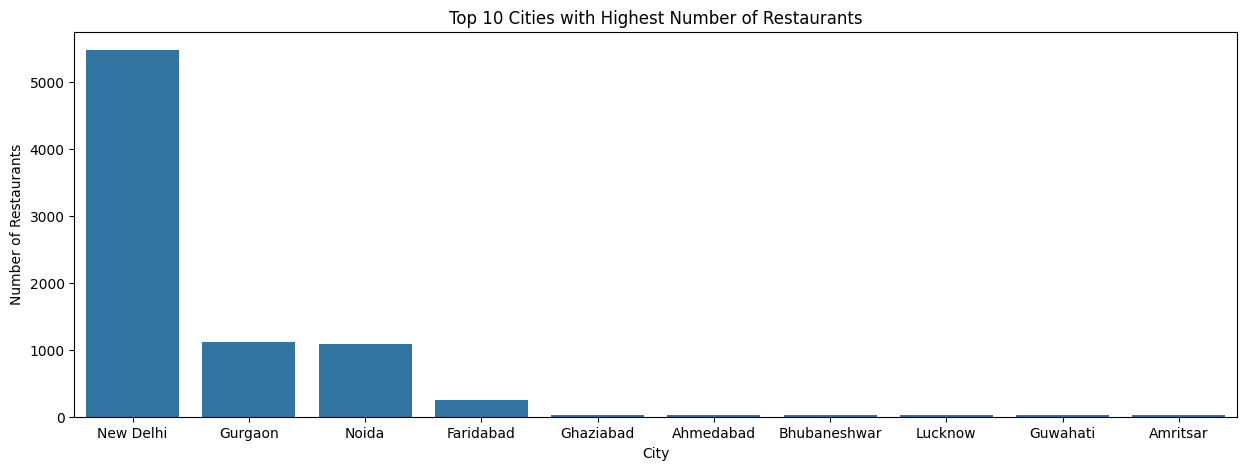

In [78]:
"""
Part 3 — Data Visualization
Create appropriate visualizations using Matplotlib and/or Seaborn.
"""
#1. Bar Chart
#a. Top 10 cities with the highest number of restaurants.
top_cities = data['City'].value_counts().head(10)
print(top_cities)
plt.figure(figsize=(15,5))
sns.barplot(y=top_cities.values, x=top_cities.index)
plt.title("Top 10 Cities with Highest Number of Restaurants")
plt.ylabel("Number of Restaurants")
plt.xlabel("City")
plt.show()

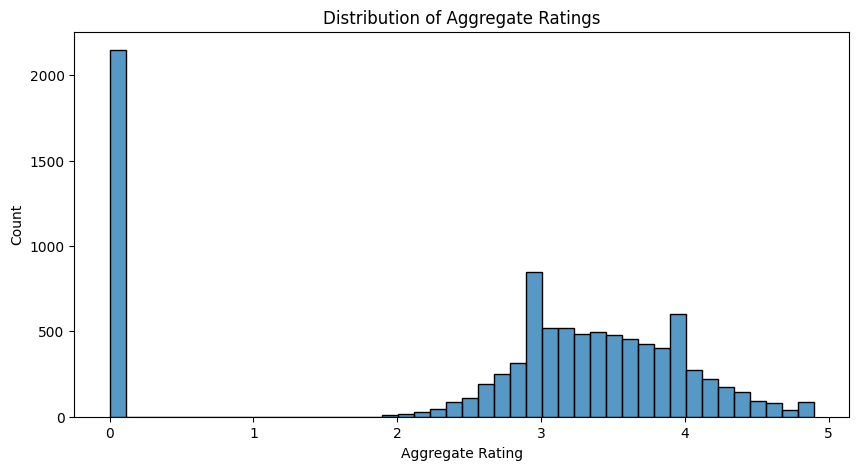

In [74]:
#2. Histogram
#a. Distribution of Aggregate Ratings.
plt.figure(figsize=(10,5))
sns.histplot(data['Aggregate rating'])
plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Count")
plt.show()

Cuisines
North Indian     2992
 Chinese         1880
 Fast Food       1314
 North Indian     968
Chinese           855
 Mughlai          780
Fast Food         672
Bakery            621
Cafe              617
 Italian          530
Name: count, dtype: int64


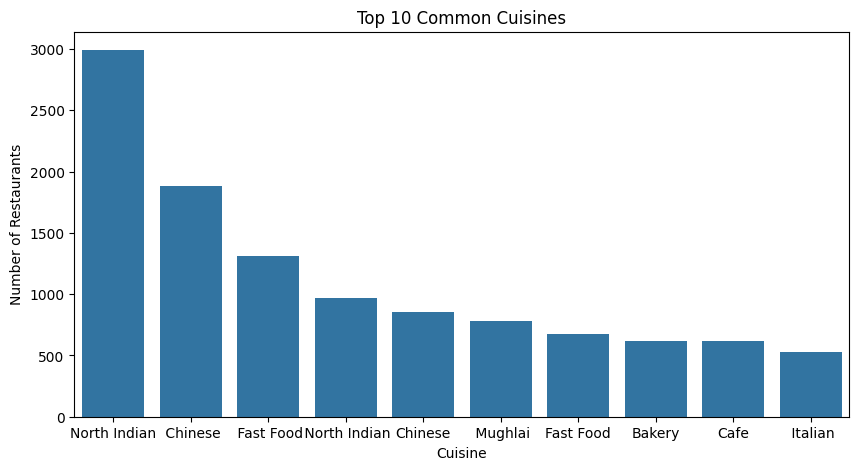

In [82]:
#3.Bar Chart
#a. Number of restaurants offering Online Delivery (Yes/No).
top_cuisines = data['Cuisines'].dropna().str.split(',').explode().value_counts().head(10)
print(top_cuisines)
plt.figure(figsize=(10,5))
sns.barplot(x=top_cuisines.index, y=top_cuisines.values)
plt.title("Top 10 Common Cuisines")
plt.ylabel("Number of Restaurants")
plt.xlabel("Cuisine")
plt.show()